# AP 155 Lab Exercise
---
## Exercise 1: Idiomatic Python

_Instructions_: 
- **Report figure (Problem 1):** Plot the 2D wave interference pattern between 2 (or more) coherent sources. Include at least 1 figure.
- **Report discussion (Problem 2):** Write a custom `matrix_multiply()`function using Python list comprehensions without external libraries (do not use `np.dot()` or `@`).
    - (i) For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
    - (ii) What are the general benefits of writing idiomatic Python?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Buhangin, Ahrystan Deniz
- _Student No._: 2024-07766
- _Section_: THR-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1 

![Description](./Figures/2source.png)

The figure shows a 2 ripple source interference pattern. Both sources are placed at symmetrical positions. Areas of constructive and destructive interference can be very visibly seen.

### Problem 2 

- i. For larger matrices, the @ operator is preferred due to its compact and more scalable nature, along with its lack of many crude iterations.
- ii. Idiomatic python is efficient, readable, and focuses much more on creating a good code workflow.

### Other comments
- Found number 2 much easier due to inexperience using matplotlib



---
## Section 2: Code

### Problem 1: 2D Wave interference (Gezerlis Problem 1.15)

Assume that the combined eﬀect of two objects dropped in a water basin can be modelled by:
$$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$ You can think of this as an updated version of Eq. (1.3) in the book, where we are dealing with the linear addition of sinusoidal waves, instead of electric-field contributions. For simplicity, take $A=1$, $k=2\pi/0.3$, $r_0 = (−1, 0)$ , and $r_1 = (1, 0)$. Since we are now faced with a density plot, you should employ, NOT `streamplot()` but, `imshow()` from `Matplotlib`; in each of $x$ and $y$ your plot should extend from $−4$ to $+4$.

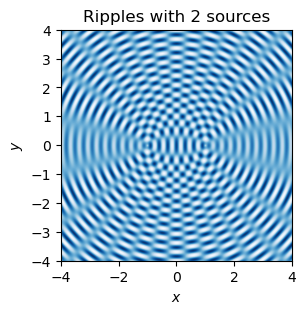

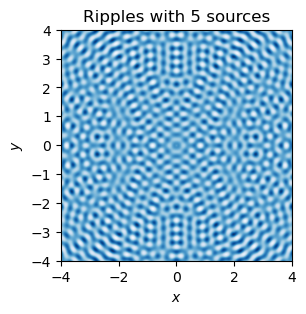

In [129]:
import matplotlib.pyplot as plt
import numpy as np
import math

pi = math.pi
A = 1
k = 2*pi/0.3
r = [[2, 3], [-2, 3], [2, -3], [-2, -3], [0,0]]

x = np.linspace(-4, 4, 500)
y = np.linspace(-4, 4, 500)
X, Y = np.meshgrid(x, y)

def getRipple(A, k, r):
    R = []
    W = 0
    for i in r:
        R.append(np.sqrt((X-i[0])**2 + (Y-i[1])**2))
    for j in R:    
        W = W + A*np.sin(k*j)
    return W

def plotRipple(r):
    plt.figure(figsize=(3, 3))
    plt.imshow(getRipple(A, k, r), cmap = 'Blues', extent = [-4, 4, -4, 4])
    plt.title('Ripples with ' + str(len(r)) + " sources")
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.savefig('/home/jovyan/Buhangin_AP155/AP155_TX1_1sAY2627/ahrystanB/Figures/'+str(len(r))+'source.png')

filePath = "Figures/5source.png"
plotRipple([[1, 0], [-1,0]])
plotRipple(r)


#### Problem 1 code summary

The code starts by defining some of the given constants along with a list **r** which can take more than just the two initial input ripple sources. After that we create a 2D coordinate grid from x, y = -4 to 4 with 500 x 500 increments, and create a getRipple function which decomposes the source position vectors and calculates the 'ripple' at any given point due to however many point sources. Lastly, we plot the resulting ripple interferences using plotRipple.

---

### Problem 2: Listcomps-maxxing

Import the `random` library (docs: https://docs.python.org/3/library/random.html). We will be using the `random.randint` function to pick random integers.

In [3]:
import random
number = random.randint(1, 9)
number

5

a. Create a function `random_integer_matrix(nrows, ncols)` that generates a matrix in the form of "list-of-lists" whose elements are random integers from $1$ to $9$. Each "sub-list" inside the main list is a row in the matrix.

In [130]:
import random
def random_integer_matrix(nrows, ncols):
    list = []
    for i in range(nrows):
        row = []
        for j in range(ncols):
            row.append(random.randint(1, 9))
        list.append(row)
    """ 
    Starting with an empty list, we iterate for the number of specified rows and construct them individually according to the 
    specified number of columns.
    """
    return list

random_integer_matrix(3, 4) # call the function to create a 3x4 matrix

[[9, 2, 2, 5], [9, 7, 8, 3], [4, 8, 5, 2]]

b. Create a function `scalar_product(list1, list2)` where you multiply each element at the same index in the two lists and sum/accumulate the results.

In [52]:
list1 = [1, 5, 7]
list2 = [3, 2, 1]

def scalar_product(list1, list2):
    sum = 0
    for k in range(len(list1)):
        sum = sum + list1[k] * list2[k]
    return sum
scalar_product(list1, list2)

20

In [ ]:
# use as many cell blocks as you want (as long as they all are functional)
# include valuable comments (even for trivial functions, a one-liner will do)

c. Create a function `transpose_matrix(orig_matrix)` which returns the transpose of any matrix also in "list-of-lists" form. Do not assume the size of the matrix; figure it out within the function. Double-check that your implementations above work. Create a $3\times4$ random integer matrix, print it out and its transpose. The values and shape between the two should be consistent.

In [131]:
matrix = [[5, 6, 9, 1], [9, 9, 9, 6], [1, 2, 2, 4]]

def transpose_matrix(orig_matrix):
    matrix_tr = []
    for i in range(len(orig_matrix[0])):
        row_tr = []
        for j in orig_matrix:
            row_tr.append(j[i])
        matrix_tr.append(row_tr)
    return matrix_tr

test = transpose_matrix(matrix)
print('Transposed matrix: ' + str(test))
print('Transpose of the transposed matrix (should output the original matrix): '+ str(transpose_matrix(test)))

Transposed matrix: [[5, 9, 1], [6, 9, 2], [9, 9, 2], [1, 6, 4]]
Transpose of the transposed matrix (should output the original matrix): [[5, 6, 9, 1], [9, 9, 9, 6], [1, 2, 2, 4]]


d. Create a function `matrix_multiply(left_matrix, right_matrix)` which performs the matrix multiplication. Do not assume the matrices follow a specific shape. Here's some tips and strategies:
* Determine how many rows and columns the left and right matrices have. Which numbers should match in order for us to have valid matrix multiplication?
* Iterating the elements of "list-of-lists" gives us the rows, but we need to iterate the columns for the right matrix.
* Use the `transpose_matrix` function, then iteratively apply `scalar_product`.

In [59]:
matrix1 = [[0, 1], [0, 1], [1, 0]]
matrix2 = [[1, 0, 1], [1, 0, 1]]

def is_multiplicable(left_matrix, right_matrix):
    if len(left_matrix) == len(right_matrix[0]):
        return True
    else:
        return False

def matrix_multiply(left_matrix, right_matrix):
    if is_multiplicable(left_matrix, right_matrix) == True:
        matrix_tr = transpose_matrix(right_matrix)
        matrix_product = []
        for i in range(len(left_matrix)):
            matrix_product.append(scalar_product(left_matrix[i], matrix_tr[i]))
        return matrix_product
    else:
        print("Matrices cannot be multiplied")

matrix_multiply(matrix1, matrix2)
    
    
    

[1, 0, 1]

#### Problem 2 code summary

The final script is a combination of our dot product and transpose functions. Both of these functions, along with the final matrix multiplication function are simply applications of nested loops. Specifically, nested loops for matrix rows then the matrix columns were most used.